# Analisis de logs distribuidos

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

#cargar dataset
df = pd.read_csv('recursos/server_logs.csv')

#parsear el tiempo 
df['timestamp_event'] = pd.to_datetime(df['timestamp_event'])

#definir que es un bad event
#crear columna is_bad que tiene valores booleanos
df['is_bad'] = (df['severity'].isin(['ERROR', 'CRITICAL'])) | (df['status_code'] >= 500)

#preparar indicador para el % de la familia de 5xx para el baseline
#otra columna booleana para identificar status_code > 500
df['is_5xx'] = df['status_code'] >= 500

print('Celda 1 ejecutada sin problemas')

Celda 1 ejecutada sin problemas


## Exploracion inicial

In [13]:
print("EXPLORACION INICIAL")
print(f"Total de logs: {len(df)}")

print("\n Severidad mas comun:")
print(df['severity'].value_counts().head(1))

print(f"\n Servicio con mas logs: ")
print(df['service_name'].value_counts().head(1))

print(f"\n Servicio con menos logs:")
print(df['service_name'].value_counts().tail(1))

print("\n Mensaje mas repetido:")
print(df["message"].value_counts().head(1))

print("\n Mensaje malo mas repetido:")
print(df[df["is_bad"] == True]['message'].value_counts().head(1))



EXPLORACION INICIAL
Total de logs: 5795

 Severidad mas comun:
severity
INFO    3542
Name: count, dtype: int64

 Servicio con mas logs: 
service_name
api-gateway    1509
Name: count, dtype: int64

 Servicio con menos logs:
service_name
notification-service    645
Name: count, dtype: int64

 Mensaje mas repetido:
message
Health check OK    1196
Name: count, dtype: int64

 Mensaje malo mas repetido:
message
Order creation failed - inventory lock timeout    197
Name: count, dtype: int64


## Deteccion de momento critico

In [ ]:
#agrupar por ventanas de 5 minutos, 
bins_5m = df.groupby(pd.Grouper(key='timestamp_event',freq='5min'))  #devuelve un objeto de agrupacion tipo DataFrameGroupBy

#calcular las metricas por ventana en una tabla nueva
analisis_temporal = bins_5m.agg(
    total_events=('timestamp_event','count'),  #total de eventos
    bad_events=('is_bad','sum'),               #suma de eventos con errores
    avg_latency_ms=('latency_ms', 'mean'),     #promedio de latencia
    total_5xx=('is_5xx', 'sum')                #suma de eventos con codigo >=500
)

#calcular tasas
analisis_temporal['bad_rate'] = analisis_temporal['bad_events'] / analisis_temporal['total_events']
analisis_temporal['%_5xx'] = (analisis_temporal['total_5xx'] / analisis_temporal['total_events'])

#aplicar filtro de significancia (>= 20 eventos)
ventanas_validas = analisis_temporal[analisis_temporal['total_events'] >= 20]

#ordenar para ver el top 5
#ordena por filas
top_5_momentos = ventanas_validas.sort_values(by='bad_rate',ascending=False).head(5)

print("\n       >Top 5 momentos MAS CRITICOS")
print(top_5_momentos[['total_events','bad_events', 'bad_rate']])

#extraer el indice (hora exacta) del top 1
hora_critica = top_5_momentos.index[0]
print(f"\n      >El momento MAS CRITICO es: {hora_critica}")




       >Top 5 momentos MAS CRITICOS
                           total_events  bad_events  bad_rate
timestamp_event                                              
2026-01-10 11:10:00+00:00           189         110  0.582011
2026-01-10 11:15:00+00:00           228         129  0.565789
2026-01-10 11:20:00+00:00           111          59  0.531532
2026-01-11 14:35:00+00:00           255         117  0.458824
2026-01-11 14:30:00+00:00           156          68  0.435897

      >El momento MAS CRITICO es: 2026-01-10 11:10:00+00:00


## Diagnostico dentro de los momentos criticos

In [21]:
#definir los limites de tiempo del incidente
inicio_incidente = hora_critica
fin_incidente = hora_critica + pd.Timedelta(minutes=5)

#filtrar por dataset original para quedarse con solo esos 5 min
df_incidente = df[(df['timestamp_event'] >= inicio_incidente) & (df['timestamp_event'] < fin_incidente)]

#filtrar solo los errores dentro de ese incidente
df_errores_incidente = df_incidente[df_incidente['is_bad'] == True]

print(f"    >Diagnostico del incidente ({inicio_incidente})")
print("\n Ranking de servicios afectados (Criterio: Cantidad de bad events):")
print(df_errores_incidente['service_name'].value_counts().head(10))

print('\n Top de 5 mensajes de error:')
print(df_errores_incidente['message'].value_counts().head(5))

print("\n Top 5 enpoints comprometidos:")
print(df_errores_incidente['endpoint'].value_counts().head(5))


    >Diagnostico del incidente (2026-01-10 11:10:00+00:00)

 Ranking de servicios afectados (Criterio: Cantidad de bad events):
service_name
orders-service       72
inventory-service    37
payment-service       1
Name: count, dtype: int64

 Top de 5 mensajes de error:
message
Order creation failed - inventory lock timeout    72
Database deadlock detected                        37
External dependency error                          1
Name: count, dtype: int64

 Top 5 enpoints comprometidos:
endpoint
/orders/cancel    26
/orders/create    25
/orders/status    21
/inv/reserve      18
/inv/stock        13
Name: count, dtype: int64


## Que Cambio (Incidente vs Baseline)

In [25]:
#el baseline es todo lo que no es el incidente
df_baseline = df[(df['timestamp_event'] < inicio_incidente) | (df['timestamp_event'] >= fin_incidente)]

#calculos del momento critico
stats_incidente = analisis_temporal.loc[hora_critica]

#calculos del baseline
total_baseline = len(df_baseline)
bad_baseline = df_baseline['is_bad'].sum()
stats_baseline = {
    'total_events': total_baseline,
    'bad_rate': bad_baseline / total_baseline if total_baseline > 0 else 0,
    'avg_latency_ms': df_baseline['latency_ms'].mean(),
    '%_5xx': (df_baseline['is_5xx'].sum() / total_baseline) * 100 if total_baseline > 0 else 0,
}

#construir la tabla de comparacion
comparacion = pd.DataFrame({
    'Incidente': stats_incidente[['total_events', 'bad_rate', 'avg_latency_ms', '%_5xx']],
    'Baseline': pd.Series(stats_baseline)
})

print("     > Incidente vs Baseline")
print(comparacion)

     > Incidente vs Baseline
                  Incidente     Baseline
total_events     189.000000  5606.000000
bad_rate           0.582011     0.140029
avg_latency_ms  1589.687831   521.094363
%_5xx              0.582011    14.002854


## Graficos Obligatorios

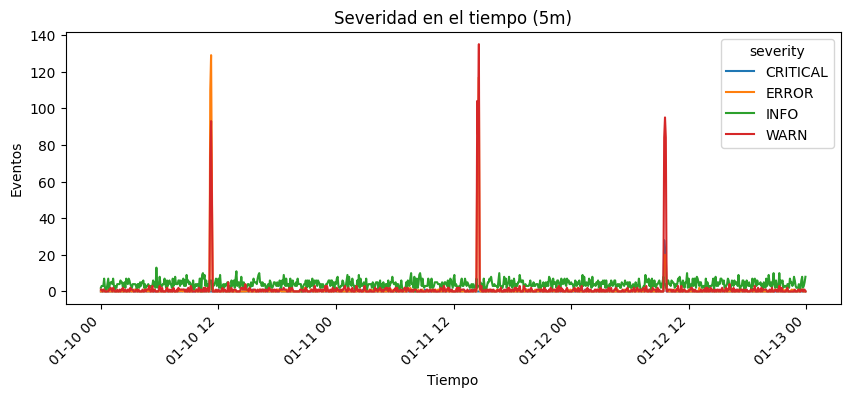

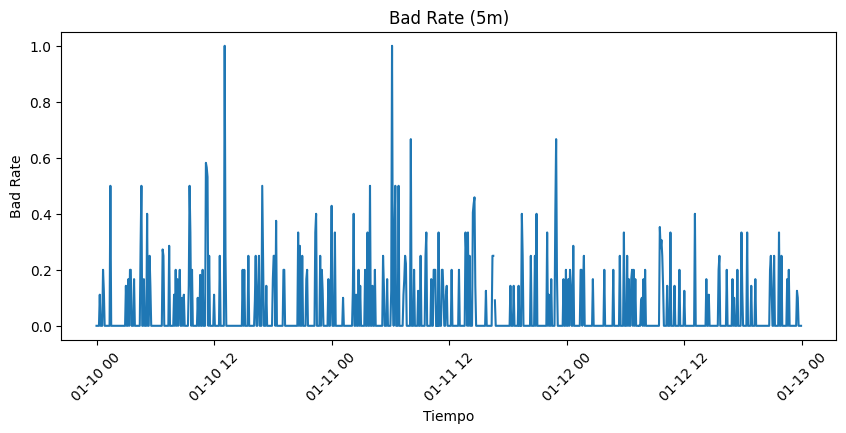

In [ ]:
# --- Gráfico 1 (simple): conteo de eventos por severidad ---
conteo_severidad = (
    df.groupby([pd.Grouper(key='timestamp_event', freq='5min'), 'severity'])
)

conteo_severidad.plot(figsize=(10,4))
plt.title('Severidad en el tiempo (5m)')
plt.xlabel('Tiempo')
plt.ylabel('Eventos')
plt.xticks(rotation=45)
plt.show()


# --- Gráfico 2 (simple): bad_rate ---
plt.figure(figsize=(10,4))
plt.plot(analisis_temporal.index, analisis_temporal['bad_rate'])
plt.title('Bad Rate (5m)')
plt.xlabel('Tiempo')
plt.ylabel('Bad Rate')
plt.xticks(rotation=45)
plt.show()